# VPU01 depstor QA/QC — PR #62 closeout + #61 anticipations

End-to-end visualization of the depression-storage pipeline for the
`gfv2_vpu01` fabric.

**Sections:**

1. Setup
2. Raster QA — eight depstor rasters (incl. `perv_binary.tif` from PR #62)
3. Per-HRU param choropleths — five gdptools-aggregated fraction params
4. Sanity check — `imperv_frac + dprst_frac + perv_frac ≈ 1`
5. Anticipated issue #61 outputs — placeholders that light up when produced
6. Out-of-scope PRMS dprst params — sourcing decision separate from depstor

Run after the full Stage 2d + Stage 4 + Stage 5 pipeline completes for
`gfv2_vpu01`. See `slurm_batch/RUNME.md` for the orchestration.


## 1. Setup

In [1]:
import glob
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
from rasterio.enums import Resampling

DATA_ROOT = Path('/caldera/hovenweep/projects/usgs/water/impd/nhgf/gfv2_param_v2')
FABRIC = 'gfv2_vpu01'
FABRIC_DIR = DATA_ROOT / FABRIC
RASTER_DIR = FABRIC_DIR / 'depstor_rasters'
PARAMS_DIR = FABRIC_DIR / 'params'
MERGED_DIR = PARAMS_DIR / 'merged'
FABRIC_GPKG = DATA_ROOT / 'input' / 'fabric' / 'NHM_01_draft.gpkg'
EXPECTED_HRU_COUNT = 11278


## 2. Raster QA — eight depstor rasters

In [2]:
RASTERS = [
    ('imperv_binary.tif', 'imperv >= 50%', 'binary'),
    ('stream_buffer.tif', '60m stream buffer', 'binary'),
    ('wbody_binary.tif', 'waterbodies', 'binary'),
    ('wbody_regions.tif', 'connected-component IDs', 'regions'),
    ('dprst_binary.tif', 'true depression storage', 'binary'),
    ('perv_binary.tif', 'NOT imperv AND NOT dprst (new in PR #62)', 'binary'),
    ('onstream_binary.tif', 'on-stream water bodies', 'binary'),
    ('drains_to_dprst.tif', 'cells draining to dprst', 'binary'),
]

rows = []
for fname, label, kind in RASTERS:
    p = RASTER_DIR / fname
    if not p.exists():
        rows.append({'raster': fname, 'status': 'MISSING'})
        continue
    with rasterio.open(p) as ds:
        arr = ds.read(1)
        nodata = ds.nodata
        valid = arr if nodata is None else arr[arr != nodata]
        row = {
            'raster': fname,
            'label': label,
            'shape': f'{ds.height}x{ds.width}',
            'dtype': str(arr.dtype),
            'nodata': nodata,
            'valid_pct': round(100 * valid.size / arr.size, 2),
            'min': float(valid.min()) if valid.size else None,
            'max': float(valid.max()) if valid.size else None,
        }
        if kind == 'binary':
            row['frac_ones'] = round(100 * (arr == 1).sum() / arr.size, 3)
        if kind == 'regions':
            row['n_regions'] = int(valid.max()) if valid.size else 0
        rows.append(row)

pd.DataFrame(rows)


,raster,label,shape,dtype,nodata,valid_pct,min,max,frac_ones,n_regions
0,imperv_binary.tif,imperv >= 50%,31405x25845,uint8,255.0,0.27,1.0,1.0,0.270,NaN
1,stream_buffer.tif,60m stream buffer,31405x25845,uint8,255.0,0.83,1.0,1.0,0.831,NaN
2,wbody_binary.tif,waterbodies,31405x25845,uint8,255.0,0.63,1.0,1.0,0.630,NaN
3,wbody_regions.tif,connected-component IDs,31405x25845,int32,0.0,0.63,1.0,864.0,NaN,864.0
4,dprst_binary.tif,true depression storage,31405x25845,uint8,255.0,0.01,1.0,1.0,0.009,NaN
5,perv_binary.tif,NOT imperv AND NOT dprst (new in PR #62),31405x25845,uint8,255.0,99.72,1.0,1.0,99.721,NaN
6,onstream_binary.tif,on-stream water bodies,31405x25845,uint8,255.0,0.62,1.0,1.0,0.621,NaN
7,drains_to_dprst.tif,cells draining to dprst,31405x25845,uint8,255.0,0.07,1.0,1.0,0.068,NaN


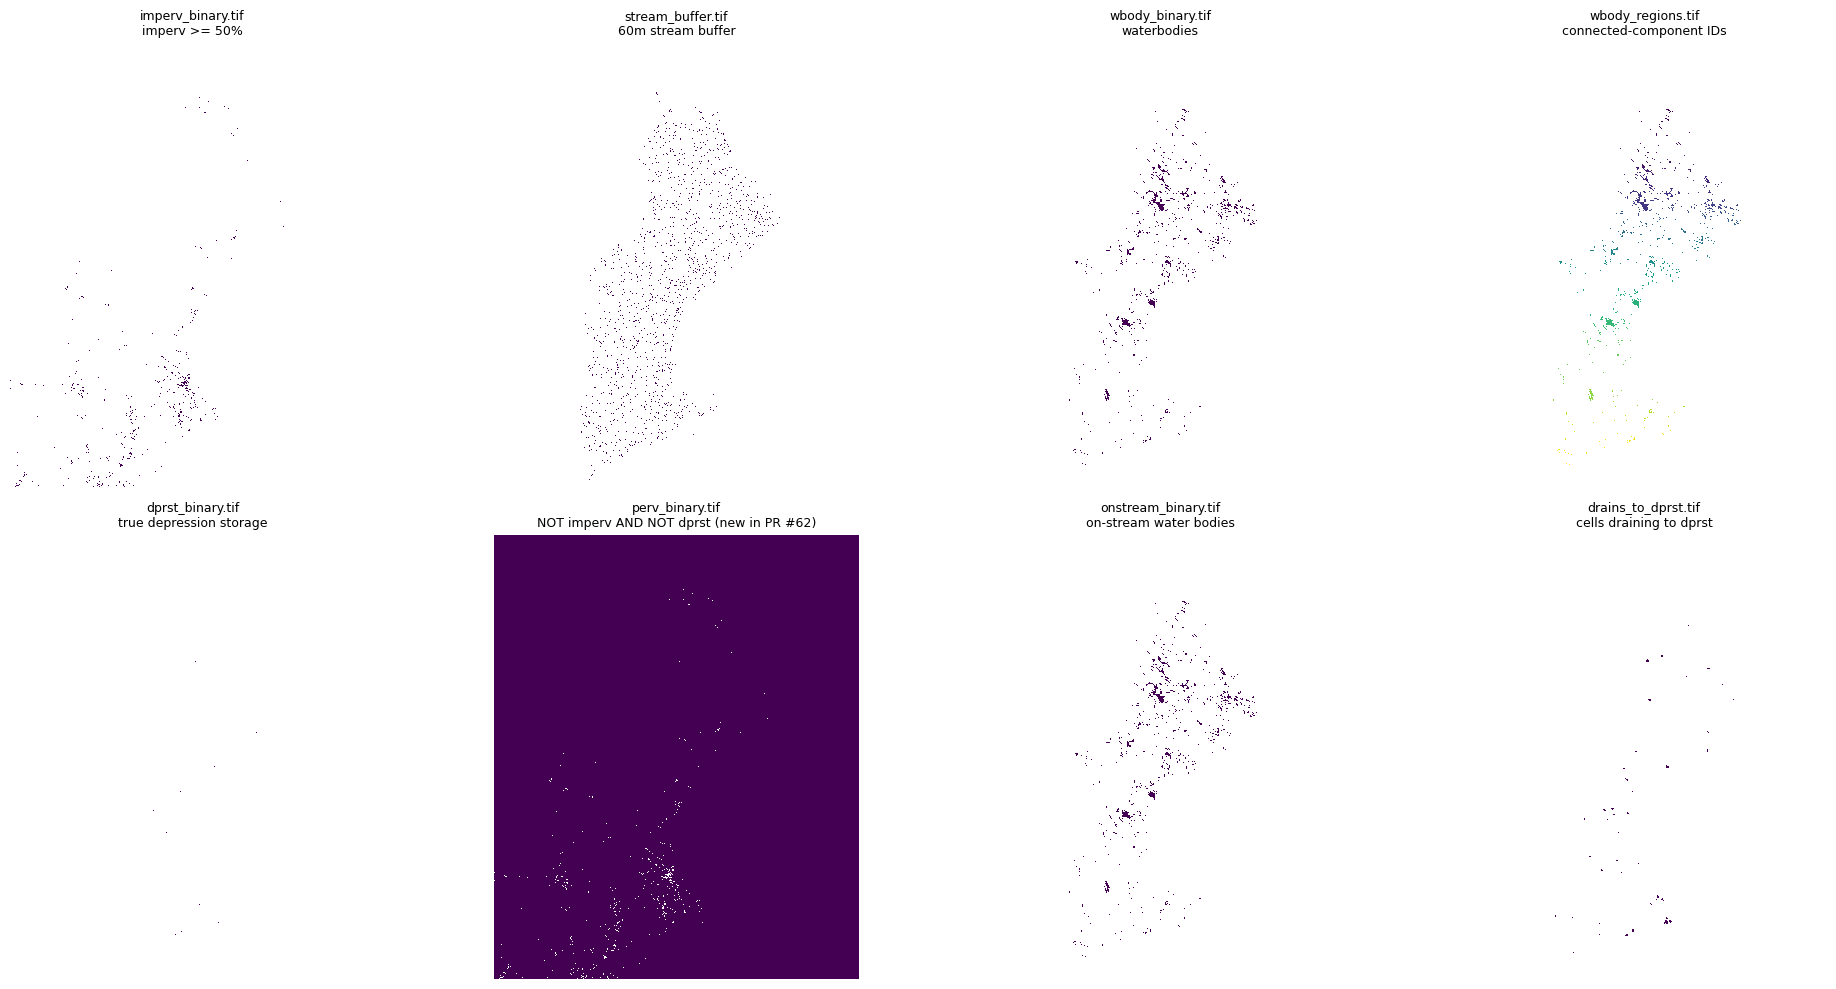

In [3]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for ax, (fname, label, kind) in zip(axes.flat, RASTERS):
    p = RASTER_DIR / fname
    if not p.exists():
        ax.set_title(f'{fname}\n(MISSING)', fontsize=10)
        ax.axis('off')
        continue
    with rasterio.open(p) as ds:
        out_shape = (1, max(1, ds.height // 50), max(1, ds.width // 50))
        thumb = ds.read(out_shape=out_shape, resampling=Resampling.nearest)[0]
        nd = ds.nodata
    if nd is not None:
        masked = np.ma.masked_equal(thumb, nd)
    else:
        masked = thumb
    ax.imshow(masked, cmap='viridis', interpolation='nearest')
    ax.set_title(f'{fname}\n{label}', fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()


## 3. Per-HRU param choropleths

In [4]:
hrus = gpd.read_file(FABRIC_GPKG, layer='nhru')
print(f'Loaded {len(hrus)} HRU polygons from {FABRIC_GPKG.name}')
print(f'Columns: {list(hrus.columns)}')
assert 'nat_hru_id' in hrus.columns, 'expected nat_hru_id'
hrus.head()


Loaded 11278 HRU polygons from NHM_01_draft.gpkg
Columns: ['vpu_agg_id', 'hru_id', 'segment_id', 'areasqkm', 'vpu', 'nat_hru_id', 'geometry']


,vpu_agg_id,hru_id,segment_id,areasqkm,vpu,nat_hru_id,geometry
0,010200051007,1.0,NaN,1.766701,01,1,"MULTIPOLYGON (((2126235 2705175, 2126235 27049..."
1,010200051008,2.0,NaN,12.289498,01,2,"MULTIPOLYGON (((2132085 2703495, 2132115 27033..."
2,010200051009,3.0,NaN,18.118801,01,3,"MULTIPOLYGON (((2130615 2686365, 2130645 26863..."
3,010500020205,4.0,NaN,3.725100,01,4,"MULTIPOLYGON (((2228775 2752965, 2228745 27528..."
4,010500020604,5.0,NaN,8.268750,01,5,"MULTIPOLYGON (((2230125 2746815, 2230095 27468..."


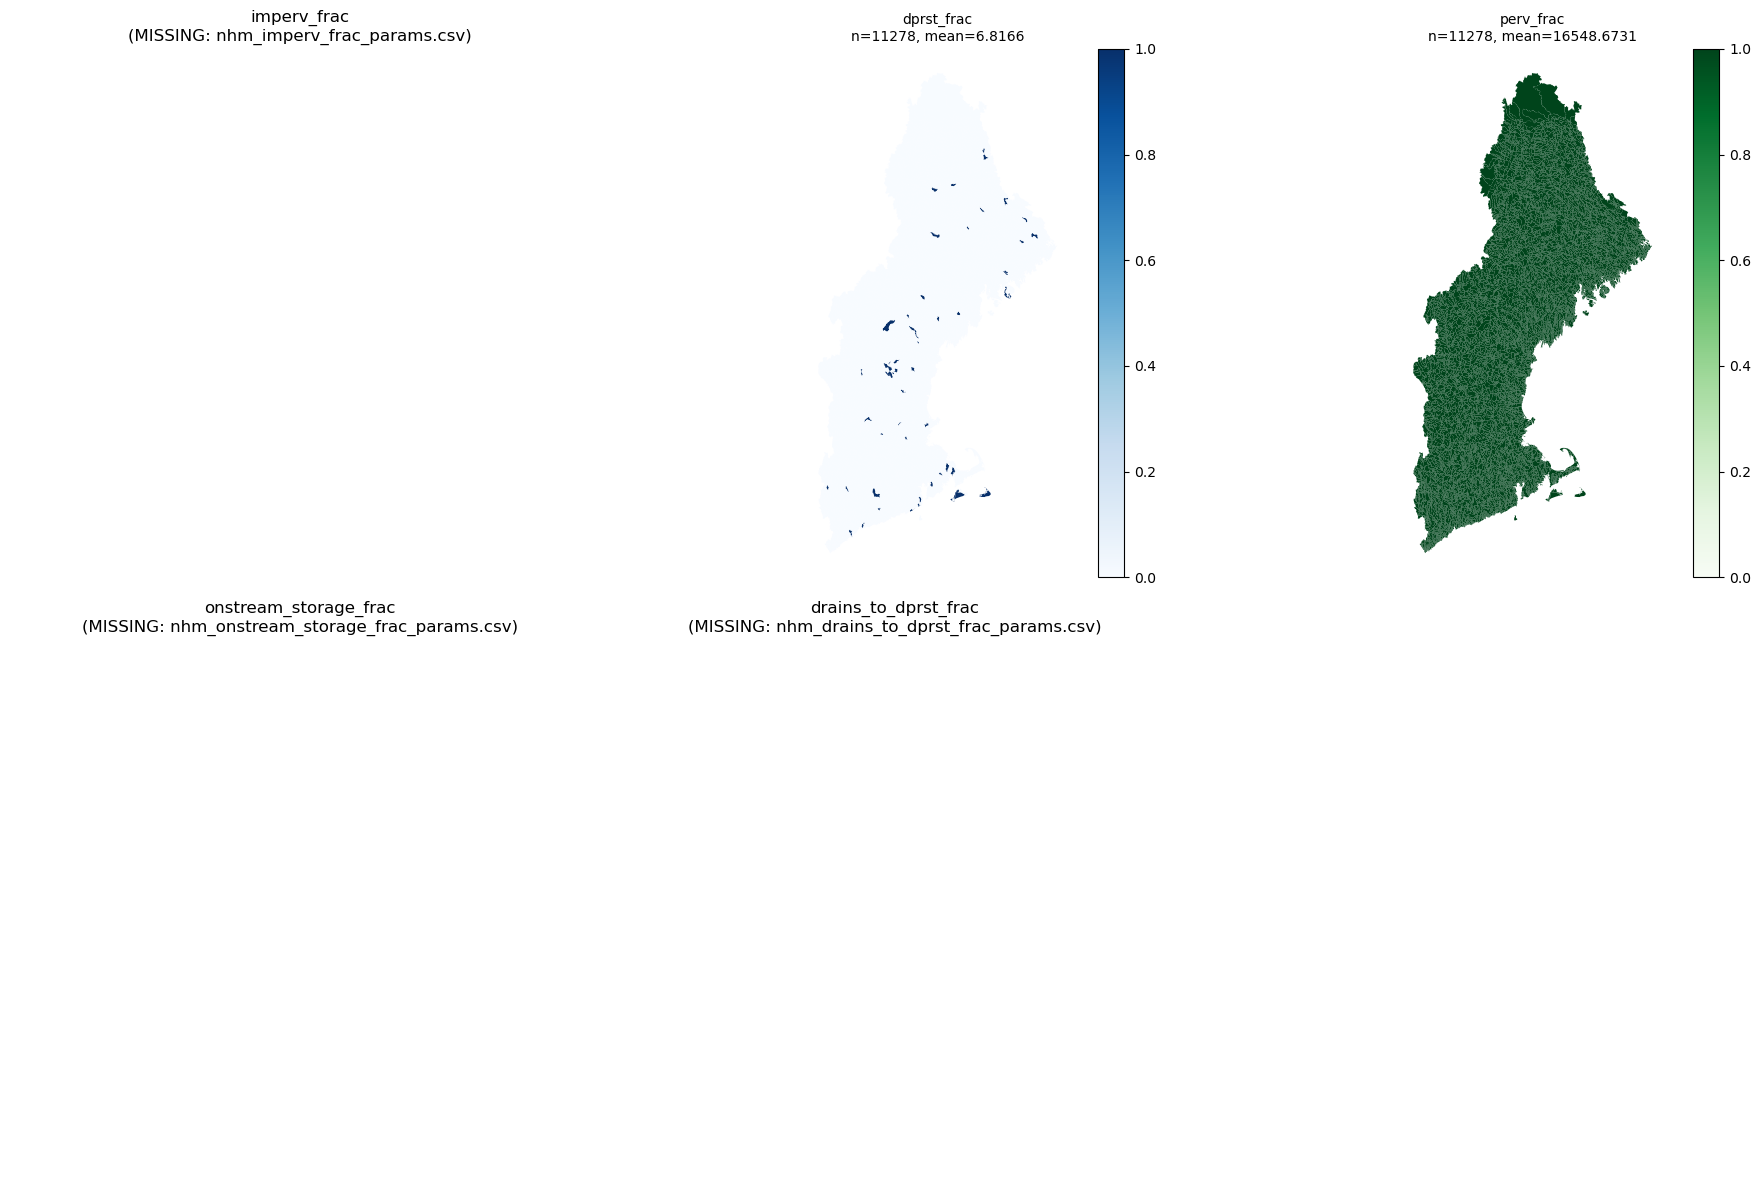

In [5]:
PARAMS = [
    ('nhm_imperv_frac_params.csv', 'imperv_frac', 'Reds'),
    ('nhm_dprst_frac_params.csv', 'dprst_frac', 'Blues'),
    ('nhm_perv_frac_params.csv', 'perv_frac', 'Greens'),
    ('nhm_onstream_storage_frac_params.csv', 'onstream_storage_frac', 'Purples'),
    ('nhm_drains_to_dprst_frac_params.csv', 'drains_to_dprst_frac', 'YlOrBr'),
]

def _value_col(df):
    return next((c for c in df.columns if c not in ('nat_hru_id', 'hru_id', 'vpu')), None)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
for ax, (fname, label, cmap) in zip(axes.flat, PARAMS):
    p = MERGED_DIR / fname
    if not p.exists():
        ax.set_title(f'{label}\n(MISSING: {fname})')
        ax.axis('off')
        continue
    df = pd.read_csv(p)
    val_col = _value_col(df)
    if val_col is None:
        ax.set_title(f'{label}\n(no value column)')
        ax.axis('off')
        continue
    merged = hrus.merge(df[['nat_hru_id', val_col]], on='nat_hru_id', how='left')
    merged.plot(column=val_col, ax=ax, cmap=cmap, vmin=0, vmax=1, legend=True,
                missing_kwds={'color': 'lightgrey'})
    ax.set_title(f'{label}\nn={merged[val_col].notna().sum()}, '
                 f'mean={merged[val_col].mean():.4f}', fontsize=10)
    ax.set_axis_off()

axes.flat[5].set_visible(False)
plt.tight_layout()
plt.show()


## 4. Sanity check — imperv_frac + dprst_frac + perv_frac ≈ 1

`perv_binary` is defined as `NOT imperv AND NOT dprst`, so the three
fractions should partition each HRU and sum to 1 within rounding /
sub-pixel partial-coverage noise.

`onstream_storage_frac` is a subset of waterbody area; cells flagged on-stream
are excluded from `dprst_binary` by region-level masking, so they fall into
`perv_binary` here. The three-way sum is not affected.


In [6]:
def _load(name):
    p = MERGED_DIR / f'nhm_{name}_params.csv'
    if not p.exists():
        return None
    df = pd.read_csv(p)
    val_col = _value_col(df)
    return df[['nat_hru_id', val_col]].rename(columns={val_col: name})

imperv = _load('imperv_frac')
dprst = _load('dprst_frac')
perv = _load('perv_frac')

if all(x is not None for x in (imperv, dprst, perv)):
    combo = imperv.merge(dprst, on='nat_hru_id').merge(perv, on='nat_hru_id')
    combo['sum'] = combo['imperv_frac'] + combo['dprst_frac'] + combo['perv_frac']
    print('Per-HRU (imperv_frac + dprst_frac + perv_frac) summary:')
    print(combo['sum'].describe())
    print()
    n_off = int(((combo['sum'] - 1).abs() > 0.01).sum())
    print(f'HRUs with |sum - 1| > 0.01: {n_off} of {len(combo)}')

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(combo['sum'], bins=50)
    ax.axvline(1.0, color='red', ls='--', label='target = 1.0')
    ax.set_xlabel('imperv_frac + dprst_frac + perv_frac')
    ax.set_ylabel('count of HRUs')
    ax.set_yscale('log')
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print('One or more inputs missing — skipping sanity check.')


One or more inputs missing — skipping sanity check.


## 5. Anticipated issue #61 outputs

Levels 4-5 of the depstor workflow (`docs/depstor_workflow.md`) produce
additional rasters and per-HRU params. These don't exist yet; placeholder
checks below light up when the relevant artefacts appear under
`{fabric}/depstor_rasters/` and `{fabric}/params/merged/`.


In [7]:
# Level 4 intermediates: getCarea_map at two TWI thresholds.
CAREA_RASTERS = [
    ('Carea_map_smidx.tif', 'Carea map @ TWI >= 15.6 (feeds smidx)'),
    ('Carea_map_carea_max.tif', 'Carea map @ TWI >= 8 (feeds carea_max)'),
]
print('--- Anticipated Level 4 rasters (issue #61) ---')
for fname, label in CAREA_RASTERS:
    p = RASTER_DIR / fname
    status = 'FOUND' if p.exists() else 'pending'
    print(f'  [{status:>7}] {fname} -- {label}')


--- Anticipated Level 4 rasters (issue #61) ---
  [pending] Carea_map_smidx.tif -- Carea map @ TWI >= 15.6 (feeds smidx)
  [pending] Carea_map_carea_max.tif -- Carea map @ TWI >= 8 (feeds carea_max)


In [8]:
# Level 3-5 per-HRU dataframes.
PENDING_PARAMS = [
    ('nhm_sro_to_dprst_perv_params.csv', 'sro_to_dprst_perv (Level 3, item 12)'),
    ('nhm_sro_to_dprst_imperv_params.csv', 'sro_to_dprst_imperv (Level 3, item 13)'),
    ('nhm_smidx_coef_params.csv', 'smidx_coef (Level 5, item 16)'),
    ('nhm_smidx_exp_params.csv', 'smidx_exp (Level 5, item 16)'),
    ('nhm_carea_max_params.csv', 'carea_max (Level 5, item 17)'),
]
print('--- Anticipated Level 3-5 per-HRU params (issue #61) ---')
for fname, label in PENDING_PARAMS:
    p = MERGED_DIR / fname
    status = 'FOUND' if p.exists() else 'pending'
    print(f'  [{status:>7}] {fname} -- {label}')


--- Anticipated Level 3-5 per-HRU params (issue #61) ---
  [pending] nhm_sro_to_dprst_perv_params.csv -- sro_to_dprst_perv (Level 3, item 12)
  [pending] nhm_sro_to_dprst_imperv_params.csv -- sro_to_dprst_imperv (Level 3, item 13)
  [pending] nhm_smidx_coef_params.csv -- smidx_coef (Level 5, item 16)
  [pending] nhm_smidx_exp_params.csv -- smidx_exp (Level 5, item 16)
  [pending] nhm_carea_max_params.csv -- carea_max (Level 5, item 17)


In [9]:
# When the params land, render them with the same choropleth machinery:
import itertools

found_pending = [(f, l) for f, l in PENDING_PARAMS if (MERGED_DIR / f).exists()]
if not found_pending:
    print('No issue #61 params materialised yet -- skipping choropleths.')
else:
    n = len(found_pending)
    cols = min(3, n)
    rows_ = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows_, cols, figsize=(6 * cols, 5 * rows_), squeeze=False)
    cmaps = itertools.cycle(['Reds', 'Blues', 'Greens', 'Purples', 'YlOrBr'])
    for ax, (fname, label), cmap in zip(axes.flat, found_pending, cmaps):
        df = pd.read_csv(MERGED_DIR / fname)
        val_col = _value_col(df)
        merged = hrus.merge(df[['nat_hru_id', val_col]], on='nat_hru_id', how='left')
        merged.plot(column=val_col, ax=ax, cmap=cmap, legend=True,
                    missing_kwds={'color': 'lightgrey'})
        ax.set_title(f'{val_col}\n{label}', fontsize=9)
        ax.set_axis_off()
    for ax in axes.flat[len(found_pending):]:
        ax.set_visible(False)
    plt.tight_layout()
    plt.show()


No issue #61 params materialised yet -- skipping choropleths.


## 6. Out-of-scope PRMS dprst params

These PRMS depression-storage parameters are **not** produced by the depstor
workflow and need a separate sourcing decision (NHM defaults table, expert
defaults, derived from DEM/wbody data, or external sources). Tracked
informally for completeness — not blocking either PR #62 or issue #61:

- `dprst_frac_open` / `dprst_frac_clos` — open vs. closed depression split
- `dprst_depth_avg` — average depression depth
- `dprst_seep_rate_clos` — closed-depression seepage rate (open is set via
  ssflux)
- `dprst_et_coef` — ET adjustment coefficient
- `op_flow_thres` — overflow threshold
- `va_open_exp` / `va_clos_exp` — volume-area exponents
- `dprst_frac_init` — initial fill fraction
- `imperv_stor_max` — max impervious surface storage

See `docs/depstor_workflow.md` and issue #61 for the full picture.
